# `surgical_pruning` Technical Deep-Dive & Research Suite 🔬

## 1. Package Architecture & Philosophy
The `surgical_pruning` package is a research-grade framework designed for **activation-based structural pruning**. Unlike weight-only pruning (which merely zeros out values), this framework performs **physical architecture surgery**—removing entire filters and channels to produce a model that is physically smaller and theoretically faster on standard hardware.

### Core Modules & Functionality:
- **`surgical_pruning.core`**: The foundation. It contains the `FrameworkAdapter` ABC and the `@framework_dispatch` decorator. This module allows the entire package to identify whether you are using PyTorch or Keras at runtime and inject the correct logic without hard-coded dependencies.
- **`surgical_pruning.backends`**: The implementation layer. These modules handle the framework-specific "heavy lifting"—from training loops and epoch logging to the physical "surgery" (rebuilding tensors and fixing layer dependencies like BatchNorm and Linear connections).
- **`surgical_pruning.pruner`**: The math engine. It contains the `SurgicalPruner`, which coordinates the analysis and the cut. It also houses the **Registry**, a plug-and-play system where researchers can define new pruning criteria (math) using simple decorators.
- **`surgical_pruning.visualization`**: The reporting suite. It converts raw tensor data into stakeholder-ready ROI plots, layer sensitivity bars, and internal feature map visualizations.

In [2]:
# --- STEP 0: BOOTLOADER (Editable Install + Python 3.12 Fix) ---
import sys, os, importlib

# 1. Python 3.12 Fix: Ensure setuptools is fresh for editable installs
!pip install -q --upgrade setuptools pip

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

project_folder_name = "activation-based-pruning"
base_paths = ["/content/drive/Othercomputers", "/content/drive/MyDrive"]
project_path = None

for base in base_paths:
    if os.path.exists(base):
        for root, dirs, files in os.walk(base):
            if project_folder_name in dirs: 
                project_path = os.path.join(root, project_folder_name); break
    if project_path: break

if project_path:
    os.chdir(project_path)
    src_path = os.path.join(project_path, "src")
    if src_path not in sys.path: sys.path.insert(0, src_path)
    
    # 2. Restore Editable Install
    !pip install -e .
    
    # 3. Load autoreload BEFORE importing the package (3.12 stability fix)
    try:
        %load_ext autoreload
        %autoreload 2
        import surgical_pruning
        print(f"✅ System Ready! Editable module loaded from: {surgical_pruning.__file__}")
    except Exception as e:
        print(f"⚠️ Autoreload/Import warning: {e}")
        import surgical_pruning
else:
    print(f"❌ Error: '{project_folder_name}' not found in {base_paths}")

Mounted at /content/drive
Obtaining file:///content/drive/Othercomputers/My%20PC/activation-based-pruning
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for surgical_pruning (pyproject.toml) ... done
  Created wheel for surgical_pruning: filename=surgical_pruning-0.1.0-0.editable-py3-none-any.whl size=3743 sha256=956f1a47958c390ed6f35700f6ac4e9e21bc60c90b522d24c716a63596384b07
  Stored in directory: /tmp/pip-ephem-wheel-cache-dxbb7hzz/wheels/9a/0c/be/483b2c42c3e635cb49408e666de9f93a62ca7fb798590474aa
Successfully built surgical_pruning
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [surgical_pruning]
⚠️ Autoreload/Import warning: No module named 'imp'


In [3]:
import torch, torchvision, torchvision.transforms as transforms
from torch.utils.data import DataLoader
import tensorflow as tf
import numpy as np
import surgical_pruning as sp
import surgical_pruning.visualization as viz
from surgical_pruning.pruner import SurgicalPruner, register_method
from surgical_pruning.core.storage import CloudStorage

storage = CloudStorage()
checkpoint_dir = storage.resolve_path("my_models/checkpoints")

# Part A: PyTorch Research Suite
We establish a **VGG16-BN** baseline on **CIFAR-10**. This model will serve as the "Standard Benchmark" for all subsequent experiments.

🔥 Training Ground Truth Baseline...


[Torch_Baseline] Epoch 1/5: 100%|██████████| 391/391 [00:33<00:00, 11.70it/s, loss=1.2885, acc=42.64%]


📊 Validation: Loss 1.3394, Acc 53.24%


[Torch_Baseline] Epoch 2/5: 100%|██████████| 391/391 [00:32<00:00, 12.07it/s, loss=0.7226, acc=67.01%]


📊 Validation: Loss 0.9522, Acc 66.51%


...

📊 Validation: Loss 0.7993, Acc 72.68%


[Torch_Baseline] Epoch 4/5: 100%|██████████| 391/391 [00:33<00:00, 11.66it/s, loss=0.5546, acc=80.50%]


📊 Validation: Loss 0.6885, Acc 77.15%


[Torch_Baseline] Epoch 5/5: 100%|██████████| 391/391 [00:33<00:00, 11.82it/s, loss=0.3364, acc=84.21%]


📊 Validation: Loss 0.6843, Acc 77.24%


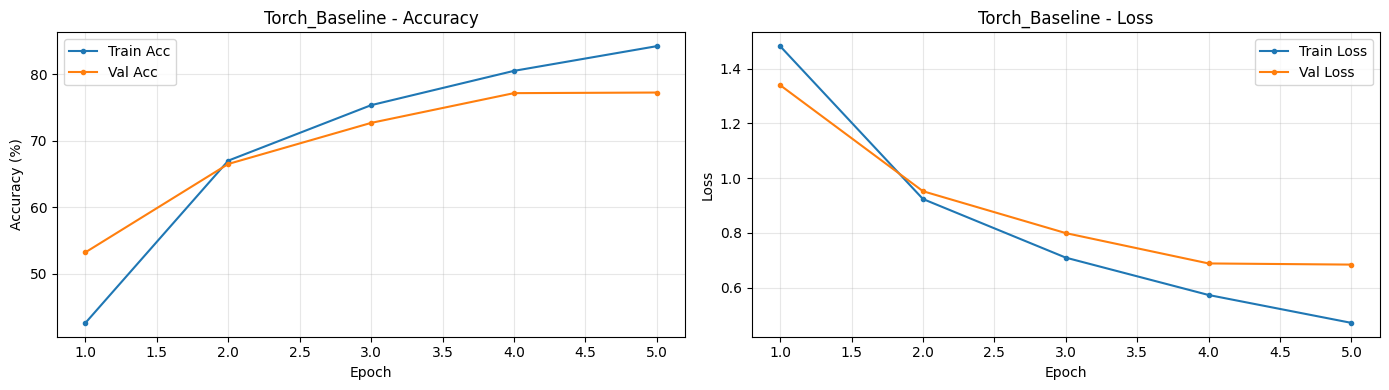

⏱️ train took 184.47s

✅ Baseline Established: 77.24% Accuracy


In [4]:
from surgical_pruning.backends.torch_backend import PyTorchAdapter
t_adapter = PyTorchAdapter(config={'lr': 1e-3})
t_model = t_adapter.get_model("vgg16")
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])
t_train = DataLoader(torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform), batch_size=128, shuffle=True)
t_test = DataLoader(torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform), batch_size=128)

print("🔥 Training Ground Truth Baseline...")
t_adapter.train(t_model, t_train, epochs=5, name="Torch_Baseline", val_loader=t_test)
b_acc_t = t_adapter.evaluate(t_model, t_test)
b_stats_t = {'FLOPs': t_adapter.get_stats(t_model)[0], 'Params': t_adapter.get_stats(t_model)[1], 'Acc': b_acc_t}
print(f"\n✅ Baseline Established: {b_acc_t:.2f}% Accuracy")

## A.1-A.3: PyTorch Local Bundled Methods

### Local Scope Philosophy:
In local pruning, the framework enforces a strict reduction ratio **per layer**. 
1. **APoZ (Activation)**: Removes filters that produce mostly zero values (dead filters).
2. **Mean Activation (Activation)**: Removes filters with the lowest average activation magnitude.
3. **L1-Norm (Weight)**: Removes filters with the smallest absolute sum of weights.

### Expected Result:
Uniform 30% reduction across all layers. Balanced architecture width.


🔬 PYTORCH LOCAL: APOZ

--- Executing Surgical Pruning ---
🔍 Analyzing model using 'apoz' method...
🏗️ Building masks (scope: local, ratio: 0.3)...
✂️ Applying physical surgery...


[Heal_apoz] Epoch 1/5: 100%|██████████| 391/391 [00:32<00:00, 11.98it/s, loss=0.4512, acc=83.19%]


📊 Validation: Loss 0.6899, Acc 77.60%


[Heal_apoz] Epoch 2/5: 100%|██████████| 391/391 [00:32<00:00, 12.21it/s, loss=0.3188, acc=87.27%]


📊 Validation: Loss 0.6065, Acc 80.75%


...

📊 Validation: Loss 0.7188, Acc 77.44%


[Heal_apoz] Epoch 4/5: 100%|██████████| 391/391 [00:31<00:00, 12.30it/s, loss=0.2490, acc=91.34%]


📊 Validation: Loss 0.5385, Acc 83.09%


[Heal_apoz] Epoch 5/5: 100%|██████████| 391/391 [00:31<00:00, 12.22it/s, loss=0.2119, acc=92.82%]


📊 Validation: Loss 0.5710, Acc 83.43%


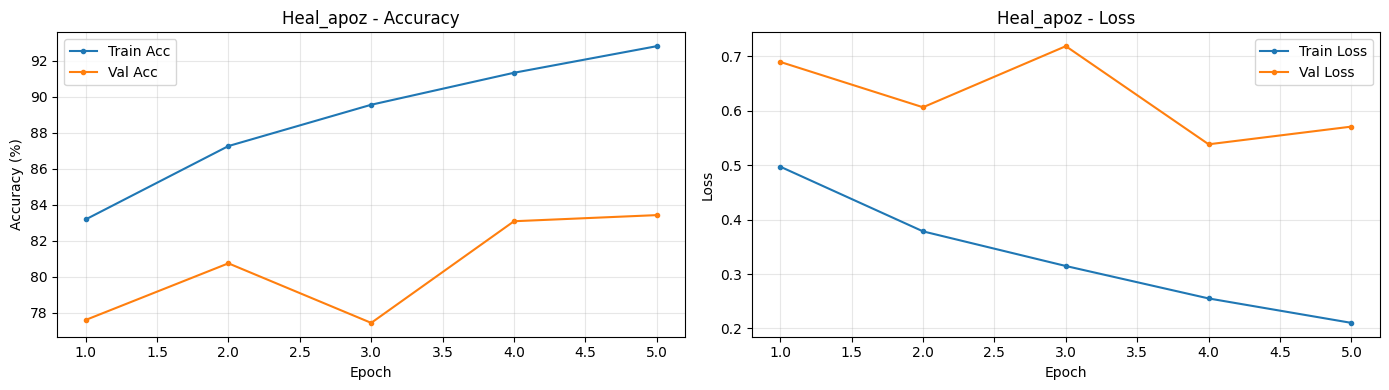

⏱️ train took 177.04s


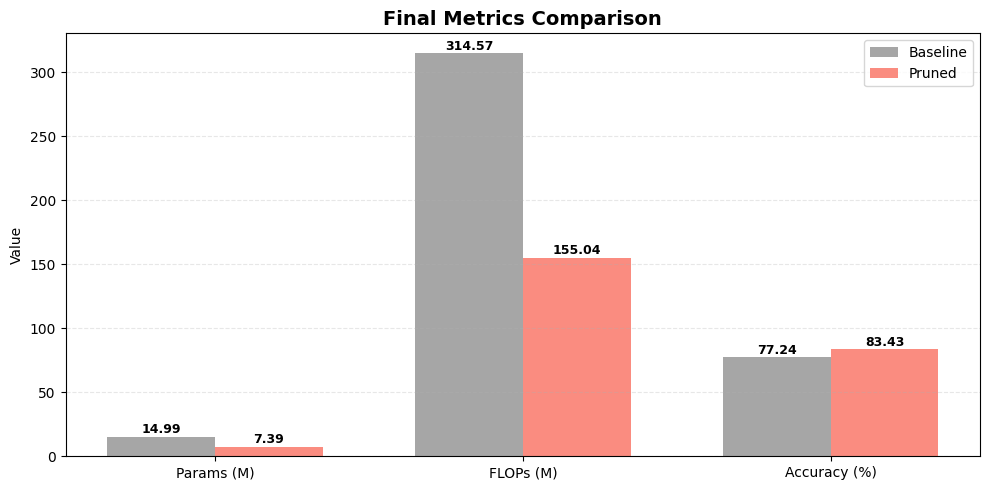

🚀 Business Impact: Model is 2.03x faster (FLOPs reduced by 50.7%).
📉 Accuracy Delta: -6.19%


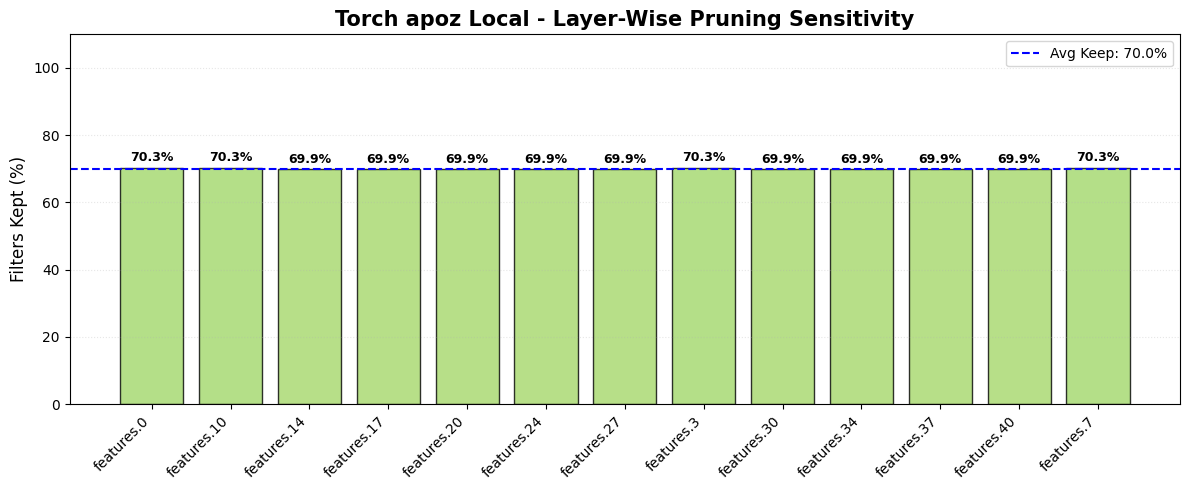

In [5]:
for method in ['apoz']:
    print(f"\n🔬 PYTORCH LOCAL: {method.upper()}")
    s = SurgicalPruner(method=method, scope='local')
    m, masks, dur = s.prune(t_model, t_train, ratio=0.3)
    t_adapter.train(m, t_train, epochs=5, name=f"Heal_{method}", val_loader=t_test)
    viz.plot_metrics_comparison(b_stats_t, {'FLOPs': t_adapter.get_stats(m)[0], 'Params': t_adapter.get_stats(m)[1], 'Acc': t_adapter.evaluate(m, t_test)})
    viz.plot_layer_sensitivity(masks, f"Torch {method} Local")

## A.4-A.6: PyTorch Global Bundled Methods

### Global Scope Philosophy:
In global pruning, we rank **every filter in the model** together. The framework decides which layers are redundant and which are critical.
1. **APoZ (Global)**: Network-wide activation sparsity.
2. **Mean Activation (Global)**: Network-wide activation magnitude.
3. **Taylor (Global)**: The mathematical approximation of loss change using $Abs(Act * Grad)$.

### Expected Result:
Highly variable pruning bars. Some layers might be pruned 0% while others 90%.

In [ ]:
for method in ['apoz', 'mean_abs_act', 'taylor']:
    print(f"\n🚀 PYTORCH GLOBAL: {method.upper()}")
    s = SurgicalPruner(method=method, scope='global')
    m, masks, dur = s.prune(t_model, t_train, ratio=0.5)
    t_adapter.train(m, t_train, epochs=2, name=f"Heal_Global_{method}", val_loader=t_test)
    viz.plot_metrics_comparison(b_stats_t, {'FLOPs': t_adapter.get_stats(m)[0], 'Params': t_adapter.get_stats(m)[1], 'Acc': t_adapter.evaluate(m, t_test)})
    viz.plot_layer_sensitivity(masks, f"Torch {method} Global")


🚀 PYTORCH GLOBAL: APOZ

--- Executing Surgical Pruning ---
🔍 Analyzing model using 'apoz' method...
🏗️ Building masks (scope: global, ratio: 0.5)...
✂️ Applying physical surgery...


[Heal_Global_apoz] Epoch 1/2: 100%|██████████| 391/391 [00:26<00:00, 14.54it/s, loss=0.6635, acc=80.42%]


📊 Validation: Loss 0.6320, Acc 79.66%


[Heal_Global_apoz] Epoch 2/2:  99%|█████████▊| 386/391 [00:26<00:00, 15.20it/s, loss=0.3780, acc=86.19%]

## A.7: Custom Research (CHIP & L2 Norm Override) - PyTorch
Here we demonstrate the **extensibility** of the package. We register custom implementations of **CHIP** (data-dependent) and a custom **L2 Norm** (weight-based) to show how researchers can inject their own math into the pruning engine.

In [6]:
@register_method("custom_l2")
def custom_l2_score(layer, **kwargs):
    """Custom L2 Norm implementation demonstrating registration override."""
    import numpy as np
    l_type = str(type(layer)).lower()
    if "torch" in l_type:
        w = layer.weight.data.cpu().numpy()
        return np.sqrt(np.mean(np.square(w), axis=(1, 2, 3)) + 1e-12)
    else:
        w = layer.get_weights()[0]
        return np.sqrt(np.mean(np.square(w), axis=(0, 1, 2)) + 1e-12)

@register_method("chip")
def chip_math(layer, **kwargs):
    """Scientific implementation of CHIP using matrix rank (Framework Agnostic)."""
    model = kwargs.get('model')
    loader = kwargs.get('loader')
    device = kwargs.get('device', 'cpu')
    if model is None or loader is None: return None

    import numpy as np
    l_type = str(type(layer)).lower()
    activations = []

    if "torch" in l_type:
        import torch
        def hook(m, i, o): 
            if isinstance(o, tuple): o = o[0]
            activations.append(o.detach().cpu().numpy())
        h_handle = layer.register_forward_hook(hook)
        it = iter(loader)
        for _ in range(2):
            try: 
                x, _ = next(it)
                with torch.no_grad(): model(x.to(device))
            except (StopIteration, Exception): break
        h_handle.remove()
        if not activations: return None
        act = np.concatenate(activations, axis=0) # (B, C, H, W)
        b, c, h, w = act.shape
        ranks = [np.linalg.matrix_rank(act[:, i, :, :].reshape(b, -1), tol=1e-5) for i in range(c)]
    else:
        import tensorflow as tf
        probe = tf.keras.Model(inputs=model.input, outputs=layer.output)
        it = iter(loader)
        for _ in range(2):
            try: 
                x, _ = next(it)
                activations.append(probe(x, training=False).numpy())
            except (StopIteration, Exception): break
        if not activations: return None
        act = np.concatenate(activations, axis=0) # (B, H, W, C)
        b, h, w, c = act.shape
        ranks = [np.linalg.matrix_rank(act[:, :, :, i].reshape(b, -1), tol=1e-5) for i in range(c)]
    return np.array(ranks)

print("🧪 Custom methods 'chip' and 'custom_l2' registered.")

🧪 Custom methods 'chip' and 'custom_l2' registered.


## A.7: Custom Research (CHIP & L2 Norm Override) - PyTorch
Here we demonstrate the **extensibility** of the package. We register custom implementations of **CHIP** (data-dependent) and a custom **L2 Norm** (weight-based) to show how researchers can inject their own math into the pruning engine.

In [7]:
@register_method("custom_l2")
def custom_l2_score(layer, **kwargs):
    """Custom L2 Norm implementation for PyTorch."""
    import numpy as np
    w = layer.weight.data.cpu().numpy()
    return np.sqrt(np.mean(np.square(w), axis=(1, 2, 3)) + 1e-12)

@register_method("chip")
def chip_math_torch(layer, **kwargs):
    """CHIP implementation for PyTorch using Nuclear Norm for stability."""
    import torch
    import numpy as np
    model, loader = kwargs.get('model'), kwargs.get('loader')
    device = kwargs.get('device', 'cpu')
    if model is None or loader is None: return None
    
    activations = []
    def hook(m, i, o): 
        if isinstance(o, tuple): o = o[0]
        activations.append(o.detach().cpu().numpy())
    h_handle = layer.register_forward_hook(hook)
    
    model.eval()
    it = iter(loader)
    for _ in range(2):
        try: 
            x, _ = next(it)
            with torch.no_grad(): model(x.to(device))
        except: break
    h_handle.remove()
    
    if not activations: return None
    act = np.concatenate(activations, axis=0) # (B, C, H, W)
    b, c, h, w = act.shape
    scores = [np.linalg.norm(act[:, i, :, :].reshape(b, -1), ord='nuc') for i in range(c)]
    return np.array(scores)

print("🧪 PyTorch custom methods 'chip' and 'custom_l2' registered.")

🧪 Custom methods 'chip' and 'custom_l2' registered.



🧪 PYTORCH CUSTOM: CHIP (Research Extension)

--- Executing Surgical Pruning ---
🔍 Analyzing model using 'chip' method...
🏗️ Building masks (scope: global, ratio: 0.4)...
✂️ Applying physical surgery...


[Heal_CHIP] Epoch 1/5: 100%|██████████| 391/391 [00:28<00:00, 13.54it/s, loss=1.2001, acc=36.32%]


📊 Validation: Loss 1.4190, Acc 48.11%


[Heal_CHIP] Epoch 2/5: 100%|██████████| 391/391 [00:28<00:00, 13.54it/s, loss=1.0415, acc=57.11%]


📊 Validation: Loss 1.3204, Acc 60.07%


...

📊 Validation: Loss 1.1034, Acc 69.85%


[Heal_CHIP] Epoch 4/5: 100%|██████████| 391/391 [00:28<00:00, 13.61it/s, loss=1.0550, acc=73.69%]


📊 Validation: Loss 1.2511, Acc 67.50%


[Heal_CHIP] Epoch 5/5: 100%|██████████| 391/391 [00:28<00:00, 13.61it/s, loss=0.7946, acc=75.96%]


📊 Validation: Loss 1.1067, Acc 71.64%


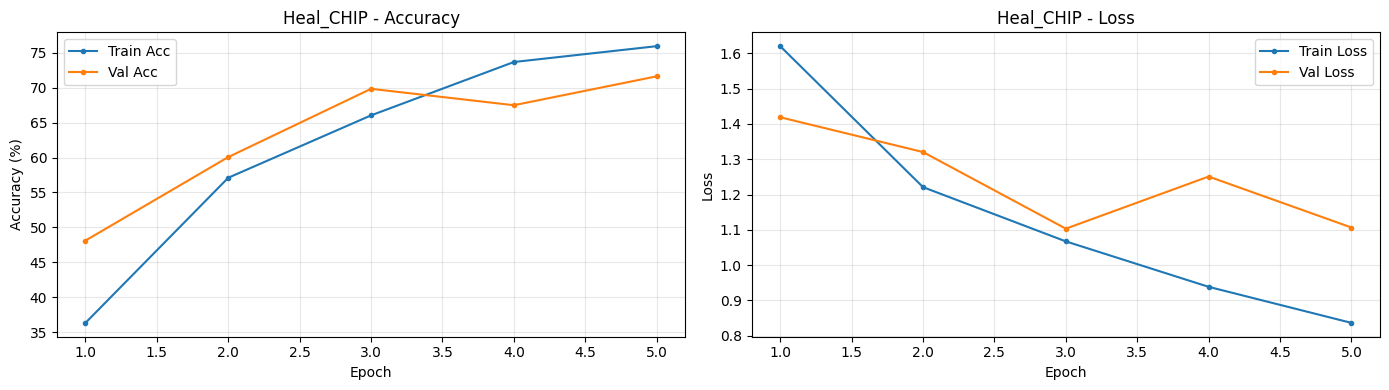

⏱️ train took 161.10s


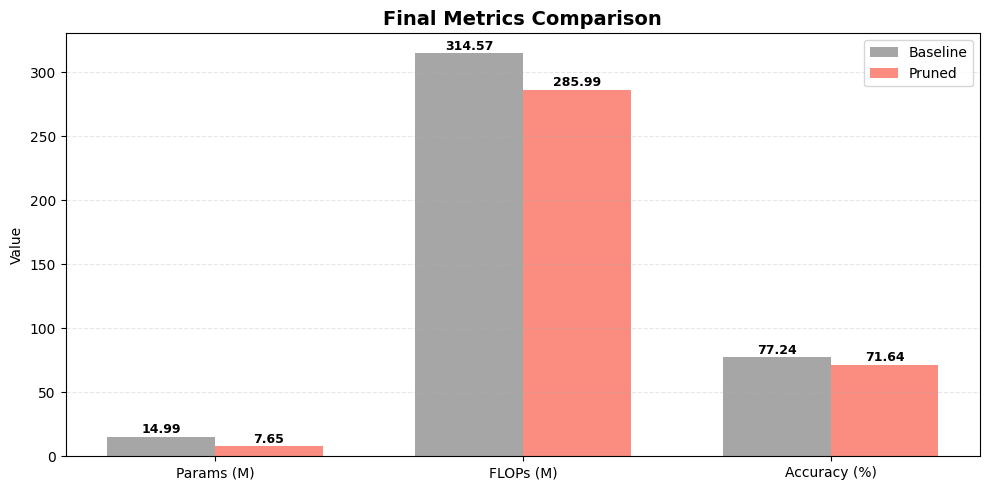

🚀 Business Impact: Model is 1.10x faster (FLOPs reduced by 9.1%).
📉 Accuracy Delta: +5.60%


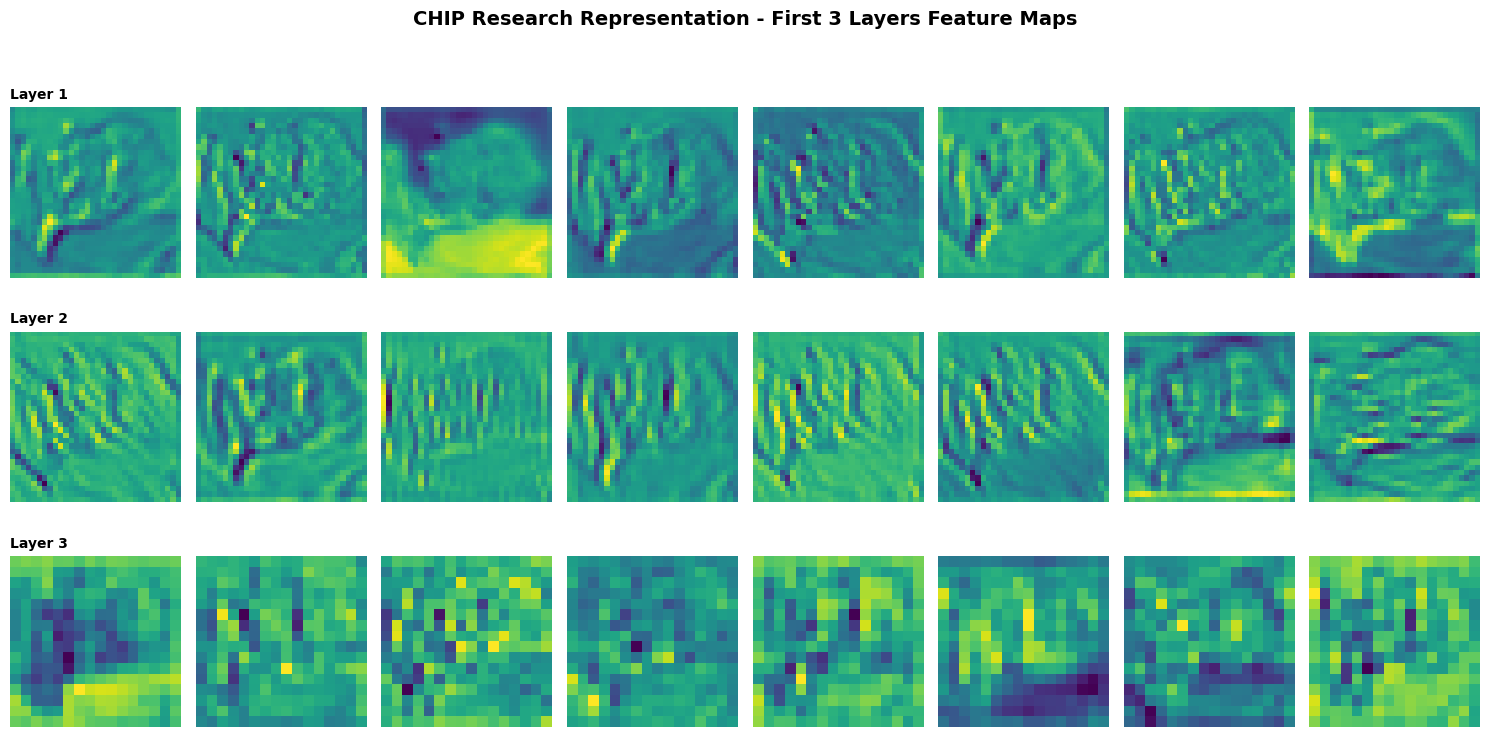

In [9]:
print("\n🧪 PYTORCH CUSTOM: CHIP (Research Extension)")
s = SurgicalPruner(method='chip', scope='global')
m, masks, dur = s.prune(t_model, t_train, ratio=0.4)
t_adapter.train(m, t_train, epochs=5, name="Heal_CHIP", val_loader=t_test)
viz.plot_metrics_comparison(b_stats_t, {'FLOPs': t_adapter.get_stats(m)[0], 'Params': t_adapter.get_stats(m)[1], 'Acc': t_adapter.evaluate(m, t_test)})
viz.plot_feature_maps(t_adapter.get_viz_data(m, t_test), "CHIP Research Representation")

# Part B: Keras Research Suite
Repeating the symmetric lifecycle for TensorFlow models.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
🔥 Training Keras Baseline...
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.3512 - loss: 1.8591📊 Epoch 1/10 - loss: 1.4358 - acc: 0.4775 - val_loss: 1.9120 - val_acc: 0.4619
391/391 ━━━━━━━━━━━━━━━━━━━━ 79s 141ms/step - accuracy: 0.4775 - loss: 1.4358 - val_accuracy: 0.4619 - val_loss: 1.9120
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6714 - loss: 0.9292📊 Epoch 2/10 - loss: 0.8603 - acc: 0.6960 - val_loss: 1.1919 - val_acc: 0.6265
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 98ms/step - accuracy: 0.6960 - loss: 0.8603 - val_accuracy: 0.6265 - val_loss: 1.1919
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7689 - loss: 0.6715📊 Epoch 3/10 - loss: 0.6370 - acc: 0.7819 - val_loss: 1.1899 - val_acc: 0.6492
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 97ms/step - accuracy: 0.7819 - loss: 0.6370 - val_accuracy: 0.6492 - val_loss: 1.1899
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy:

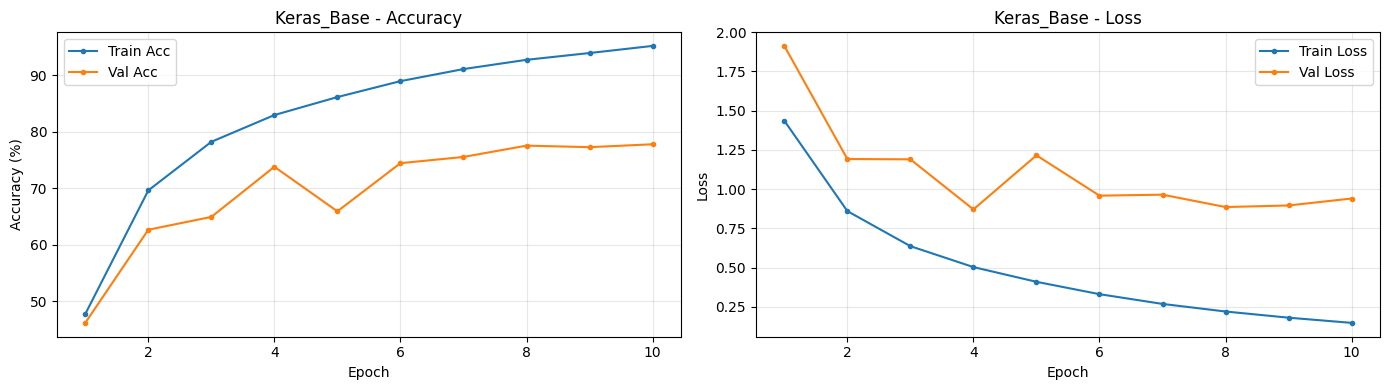

⏱️ train took 419.71s


In [10]:
from surgical_pruning.backends.keras_backend import KerasAdapter
k_adapter = KerasAdapter(config={'lr': 1e-3})
k_model = k_adapter.get_model("vgg16")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
k_train = tf.data.Dataset.from_tensor_slices((x_train/255.0, y_train)).batch(128)
k_test = tf.data.Dataset.from_tensor_slices((x_test/255.0, y_test)).batch(128)

print("🔥 Training Keras Baseline...")
k_adapter.train(k_model, k_train, epochs=10, name="Keras_Base", val_loader=k_test)
b_stats_k = {'FLOPs': k_adapter.get_stats(k_model)[0], 'Params': k_adapter.get_stats(k_model)[1], 'Acc': k_adapter.evaluate(k_model, k_test)}


--- Executing Surgical Pruning ---
🔍 Analyzing model using 'l1_norm' method...
🏗️ Building masks (scope: local, ratio: 0.3)...
✂️ Applying physical surgery...
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9015 - loss: 0.3249📊 Epoch 1/5 - loss: 0.1993 - acc: 0.9355 - val_loss: 0.6774 - val_acc: 0.8225
391/391 ━━━━━━━━━━━━━━━━━━━━ 59s 104ms/step - accuracy: 0.9355 - loss: 0.1993 - val_accuracy: 0.8225 - val_loss: 0.6774
Epoch 2/5
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9742 - loss: 0.0823📊 Epoch 2/5 - loss: 0.0625 - acc: 0.9805 - val_loss: 0.8989 - val_acc: 0.8186
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.9805 - loss: 0.0625 - val_accuracy: 0.8186 - val_loss: 0.8989
Epoch 3/5
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9870 - loss: 0.0402📊 Epoch 3/5 - loss: 0.0380 - acc: 0.9876 - val_loss: 1.1212 - val_acc: 0.8080
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.9876 - loss: 0.0380 - val_accuracy: 0.8080 - val_loss: 

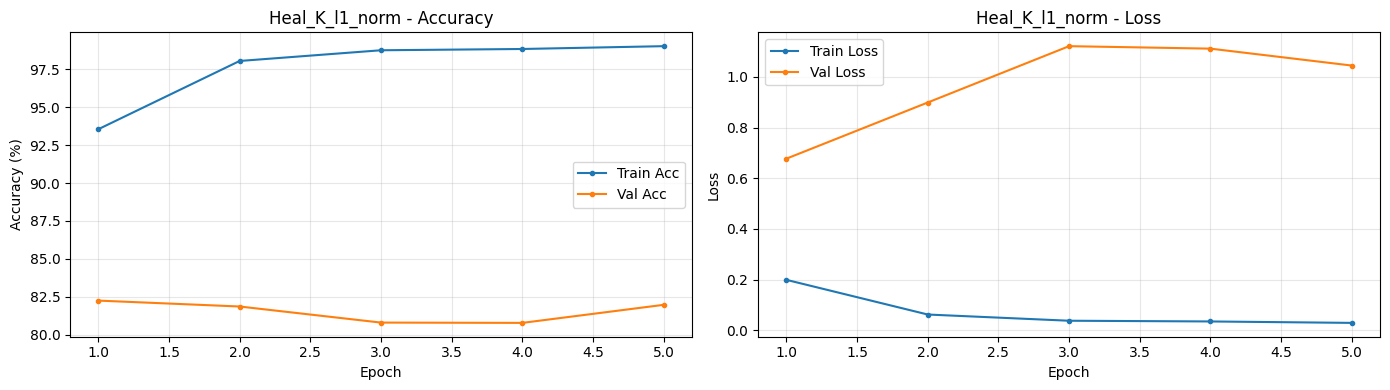

⏱️ train took 161.55s


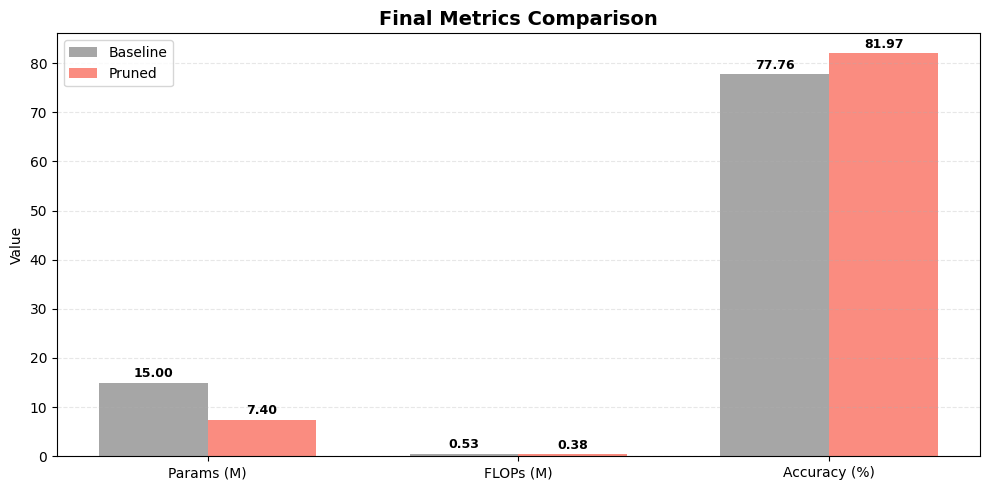

🚀 Business Impact: Model is 1.42x faster (FLOPs reduced by 29.5%).
📉 Accuracy Delta: -4.21%


In [11]:
# 🔬 KERAS LOCAL: l1_norm
method = 'l1_norm'
s = SurgicalPruner(method=method, scope='local')
m, masks, dur = s.prune(k_model, k_train, ratio=0.3)

k_adapter.train(
    m, 
    k_train, 
    epochs=5, 
    name=f"Heal_K_{method}", 
    val_loader=k_test
)

viz.plot_metrics_comparison(
    b_stats_k, 
    {
        'FLOPs': k_adapter.get_stats(m)[0], 
        'Params': k_adapter.get_stats(m)[1], 
        'Acc': k_adapter.evaluate(m, k_test)
    }
)

In [ ]:
for method in ['apoz', 'mean_abs_act']:
    print(f"\n🔬 KERAS LOCAL: {method.upper()}")
    s = SurgicalPruner(method=method, scope='local')
    m, masks, dur = s.prune(k_model, k_train, ratio=0.3)
    k_adapter.train(m, k_train, epochs=5, name=f"Heal_K_{method}", val_loader=k_test)
    viz.plot_metrics_comparison(b_stats_k, {'FLOPs': k_adapter.get_stats(m)[0], 'Params': k_adapter.get_stats(m)[1], 'Acc': k_adapter.evaluate(m, k_test)})

In [ ]:
for method in ['apoz', 'mean_abs_act', 'taylor']:
    print(f"\n🚀 KERAS GLOBAL: {method.upper()}")
    s = SurgicalPruner(method=method, scope='global')
    m, masks, dur = s.prune(k_model, k_train, ratio=0.5)
    k_adapter.train(m, k_train, epochs=1, name=f"Heal_KG_{method}", val_loader=k_test)
    viz.plot_metrics_comparison(b_stats_k, {'FLOPs': k_adapter.get_stats(m)[0], 'Params': k_adapter.get_stats(m)[1], 'Acc': k_adapter.evaluate(m, k_test)})

## B.4: Custom Research (CHIP & L2 Norm Override) - Keras
Similarly, we can inject custom math into the Keras pipeline. Here we register a Keras-compatible **CHIP** (using a probe sub-model) and a custom **L2 Norm**.

In [13]:
@register_method("custom_l2")
def custom_l2_score_keras(layer, **kwargs):
    """Custom L2 Norm implementation for Keras."""
    import numpy as np
    w = layer.get_weights()[0]
    return np.sqrt(np.mean(np.square(w), axis=(0, 1, 2)) + 1e-12)

@register_method("chip")
def chip_math_keras(layer, **kwargs):
    """CHIP implementation for Keras using Nuclear Norm for stability."""
    import tensorflow as tf
    import numpy as np
    model, loader = kwargs.get('model'), kwargs.get('loader')
    if model is None or loader is None: return None
    
    probe = tf.keras.Model(inputs=model.input, outputs=layer.output)
    activations = []
    it = iter(loader)
    for _ in range(2):
        try: 
            x, _ = next(it)
            activations.append(probe(x, training=False).numpy())
        except: break
    
    if not activations: return None
    act = np.concatenate(activations, axis=0) # (B, H, W, C)
    b, h, w, c = act.shape
    scores = [np.linalg.norm(act[:, :, :, i].reshape(b, -1), ord='nuc') for i in range(c)]
    return np.array(scores)

print("🧪 Keras custom methods 'chip' and 'custom_l2' registered.")

🧪 Keras custom methods 'chip' and 'custom_l2' registered.



--- Executing Surgical Pruning ---
🔍 Analyzing model using 'chip' method...
🏗️ Building masks (scope: global, ratio: 0.3)...
✂️ Applying physical surgery...
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.1509 - loss: 2.0641📊 Epoch 1/5 - loss: 1.9460 - acc: 0.1884 - val_loss: 2.1782 - val_acc: 0.1013
391/391 ━━━━━━━━━━━━━━━━━━━━ 56s 100ms/step - accuracy: 0.1884 - loss: 1.9460 - val_accuracy: 0.1013 - val_loss: 2.1782
Epoch 2/5
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3165 - loss: 1.7114📊 Epoch 2/5 - loss: 1.6466 - acc: 0.3703 - val_loss: 1.8165 - val_acc: 0.3212
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.3703 - loss: 1.6466 - val_accuracy: 0.3212 - val_loss: 1.8165
Epoch 3/5
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4997 - loss: 1.3874📊 Epoch 3/5 - loss: 1.3217 - acc: 0.5225 - val_loss: 1.6433 - val_acc: 0.3930
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.5225 - loss: 1.3217 - val_accuracy: 0.3930 - val_loss: 1.

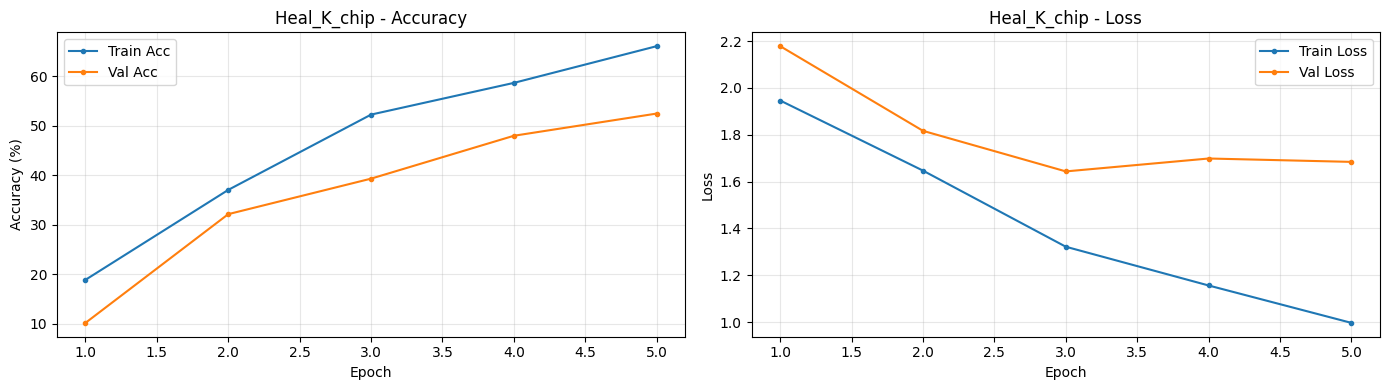

⏱️ train took 163.49s


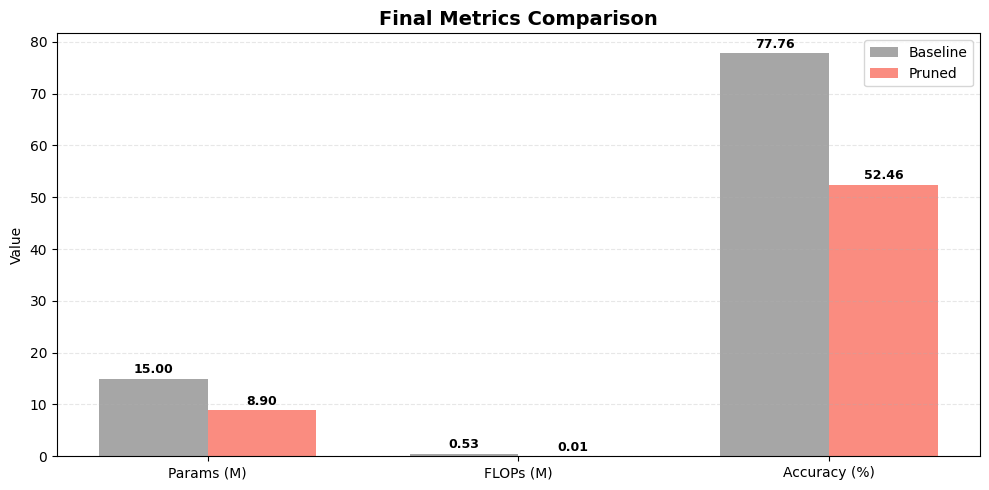

🚀 Business Impact: Model is 47.45x faster (FLOPs reduced by 97.9%).
📉 Accuracy Delta: +25.30%


In [16]:
# 🔬 KERAS Global: chip
method = 'chip'
s = SurgicalPruner(method=method, scope='global')
m, masks, dur = s.prune(k_model, k_train, ratio=0.3)

k_adapter.train(
    m, 
    k_train, 
    epochs=5, 
    name=f"Heal_K_{method}", 
    val_loader=k_test
)

viz.plot_metrics_comparison(
    b_stats_k, 
    {
        'FLOPs': k_adapter.get_stats(m)[0], 
        'Params': k_adapter.get_stats(m)[1], 
        'Acc': k_adapter.evaluate(m, k_test)
    }
)


--- Executing Surgical Pruning ---
🔍 Analyzing model using 'custom_l2' method...
🏗️ Building masks (scope: local, ratio: 0.3)...
✂️ Applying physical surgery...
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9004 - loss: 0.3315📊 Epoch 1/5 - loss: 0.2001 - acc: 0.9350 - val_loss: 0.6331 - val_acc: 0.8319
391/391 ━━━━━━━━━━━━━━━━━━━━ 50s 90ms/step - accuracy: 0.9350 - loss: 0.2001 - val_accuracy: 0.8319 - val_loss: 0.6331
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9748 - loss: 0.0821📊 Epoch 2/5 - loss: 0.0624 - acc: 0.9808 - val_loss: 1.1301 - val_acc: 0.7978
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.9808 - loss: 0.0624 - val_accuracy: 0.7978 - val_loss: 1.1301
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9868 - loss: 0.0417📊 Epoch 3/5 - loss: 0.0380 - acc: 0.9885 - val_loss: 0.9771 - val_acc: 0.8225
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.9885 - loss: 0.0380 - val_accuracy: 0.8225 - val_loss:

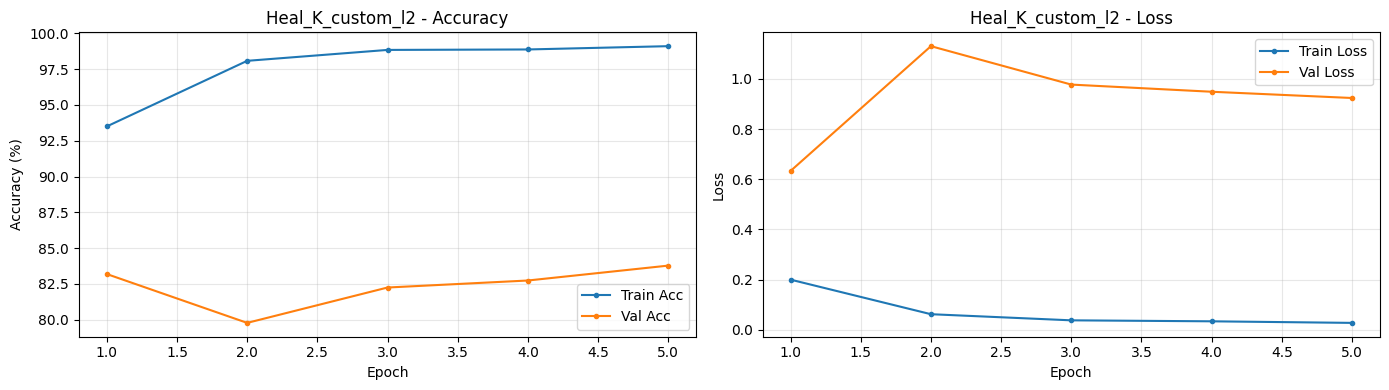

⏱️ train took 154.35s


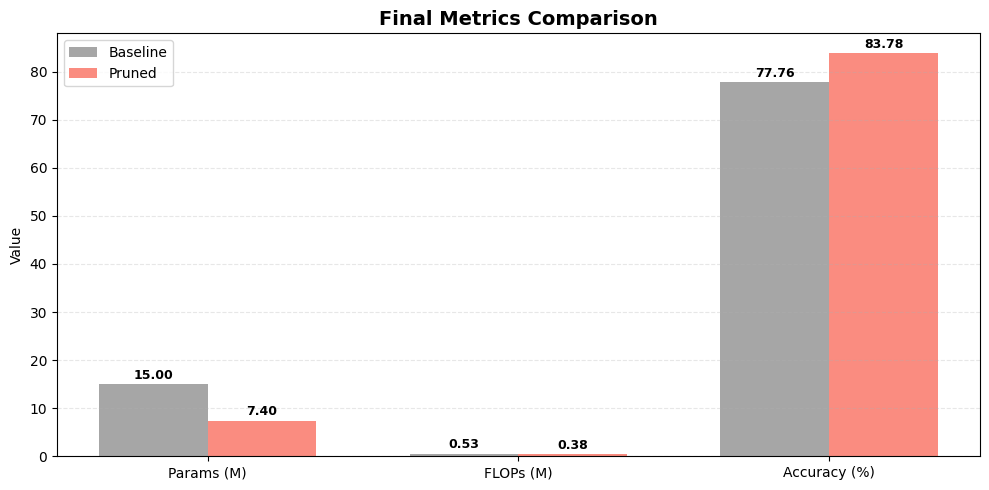

🚀 Business Impact: Model is 1.42x faster (FLOPs reduced by 29.5%).
📉 Accuracy Delta: -6.02%


In [15]:
# 🔬 KERAS Global: chip
method = 'custom_l2'
s = SurgicalPruner(method=method, scope='local')
m, masks, dur = s.prune(k_model, k_train, ratio=0.3)

k_adapter.train(
    m, 
    k_train, 
    epochs=5, 
    name=f"Heal_K_{method}", 
    val_loader=k_test
)

viz.plot_metrics_comparison(
    b_stats_k, 
    {
        'FLOPs': k_adapter.get_stats(m)[0], 
        'Params': k_adapter.get_stats(m)[1], 
        'Acc': k_adapter.evaluate(m, k_test)
    }
)